<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/Day26_%ED%96%89%EB%B3%B5%EC%A7%80%EC%88%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Day26

세계 행복지수 관련 캐글(Kaggle) 데이터는 매년 발표되는 "World Happiness Report"에 기반한 데이터셋입니다. 이 보고서는 국가별로 사람들이 자신의 삶에 대해 얼마나 행복하다고 느끼는지를 평가하며, 여러 가지 요소를 통해 그 결과를 산출합니다. 2019년 데이터는 해당 연도에 발표된 세계 행복 보고서를 기반으로 하며, 각 국가의 행복 지수를 나타내는 여러 지표를 포함하고 있습니다.

세계 행복 보고서에서 사용하는 주요 지표는 다음과 같습니다:

GDP per Capita(1인당 국내총생산): 경제적 풍요로움을 나타냅니다.

* Social Support(사회적 지지): 사람이 위기 상황에 처했을 때 의지할 수 있는 사람이 있는지 여부를 나타냅니다.
* Healthy Life Expectancy(건강한 수명 기대치): 건강한 상태에서 살 수 있는 예상 기간을 나타냅니다.
* Freedom to Make Life Choices(자유도): 개인이 자신의 삶을 자유롭게 선택하고 결정할 수 있는 정도를 나타냅니다.
* Generosity(관대함): 기부와 같은 관대한 행동의 빈도를 나타냅니다.
* Perceptions of Corruption(부패 인식): 정부나 기업 등에서의 부패가 얼마나 심각하다고 인식되는지를 나타냅니다.

이 데이터셋은 연구자, 데이터 과학자, 정책 입안자가 각 국가의 행복 수준을 이해하고, 행복에 영향을 미치는 다양한 요소를 분석할 수 있도록 합니다. 캐글(Kaggle)에서는 이 데이터를 사용해 데이터 분석, 시각화, 머신러닝 모델 개발 등 다양한 프로젝트에 활용할 수 있습니다.

2019년 데이터를 기반으로 분석을 진행할 것입니다. 이를 통해 각국의 행복 지수가 어떤 요소에 의해 영향을 받는지, 시간에 따른 변화 추이 등을 파악할 수 있으며, 국가별 정책이나 사회적 환경이 행복에 미치는 영향에 대한 인사이트를 얻을 수 있습니다. 데이터 분석 또는 머신러닝 모델을 개발할 때는 이러한 지표들을 변수로 사용하여 국가별 행복 지수를 예측하거나, 행복 지수에 가장 큰 영향을 미치는 요소를 파악하는 등의 작업을 할 수 있습니다.

### 이 수업에서는 그냥 csv 파일을 임포트해서 사용하겠지만 나중에 캐글에서 직접 가져오는 방법을 써 보셔도 좋습니다 (하지만 오래된 데이터의 경우 아카이브 되는 경우가 많아서 에러가 발생할 수 있으므로 여기서는 아래 있는 파일 임포트 방법으로 합니다)
  

In [ ]:
# Kaggle API 설치
#! pip install -q kaggle



1.   Colab 환경에서 kaggle.json 파일을 사용하여 Kaggle API에 접근하려면 다음 단계를 따르세요:

Kaggle API 키(kaggle.json) 다운로드:
* Kaggle에 로그인 한 뒤 Account로 접속
* https://www.kaggle.com/settings에서
* API > Create New Token > kaggle.json 파일을 다운로드


Colab에 파일 업로드:
Colab 노트북에서 다음 코드를 실행하여 kaggle.json 파일을 업로드합니다:

    from google.colab import files
    files.upload()

파일을 올바른 디렉토리로 이동:
업로드한 kaggle.json 파일을 Kaggle 디렉토리로 이동시키는 코드를 실행합니다.

Colab 환경에서는 아래와 같이 실행할 수 있습니다:

    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/

파일 권한 변경:
Kaggle API 키를 안전하게 보호하기 위해 파일 권한을 변경합니다. 다음 명령어를 실행합니다:

    !chmod 600 ~/.kaggle/kaggle.json

이제 Colab에서 Kaggle API를 사용하여 데이터셋을 다운로드하거나 Kaggle과 상호 작용할 수 있습니다.
예를 들어, 특정 데이터셋을 다운로드하려면 다음과 같이 실행할 수 있습니다:

    !kaggle datasets download -d [DATASET_NAME]



In [ ]:
#다운로드한 kaggle.json파일을 업로드
# from google.colab import files
# files.upload()

In [ ]:
# Kaggle Directory 생성
# ! mkdir ~/.kaggle

In [ ]:
# ! cp kaggle.json ~/.kaggle/

In [ ]:
# ! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

### 여기부터 하세요

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 자료에 있는 2019 행복지수 파일을 업로드합니다 (World Happiness Data 폴더에서 2019.csv를 가기고 옵니다)
from google.colab import files
files.upload()

Saving 2019.csv to 2019.csv


{'2019.csv': b'Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption\r\n1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393\r\n2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410\r\n3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341\r\n4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118\r\n5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298\r\n6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343\r\n7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373\r\n8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380\r\n9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308\r\n10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226\r\n11,Australia,7.228,1.372,1.548,1.036,0.557,0.332,0.290\r\n12,Costa Rica,7.167,1.034,1.441,0.963,0.558,0.144,0.093\r\n13,Israel,7.139,1.276,1.455,1.029,0.371,0.261,0.082\r\n14,Luxembourg,7.090,1.609,1.479,1.012,0.526,0.194,0.316\r\n15,United Kingdom,7.054,1.333,1.53

In [ ]:
df = pd.read_csv('2019.csv')
df.head(3)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341


In [ ]:
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [ ]:
df.rename(columns={'Country or region': 'Country', 'Score': 'Happiness Score'}, inplace=True)
df.head(3)

,Overall rank,Country,Happiness Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341


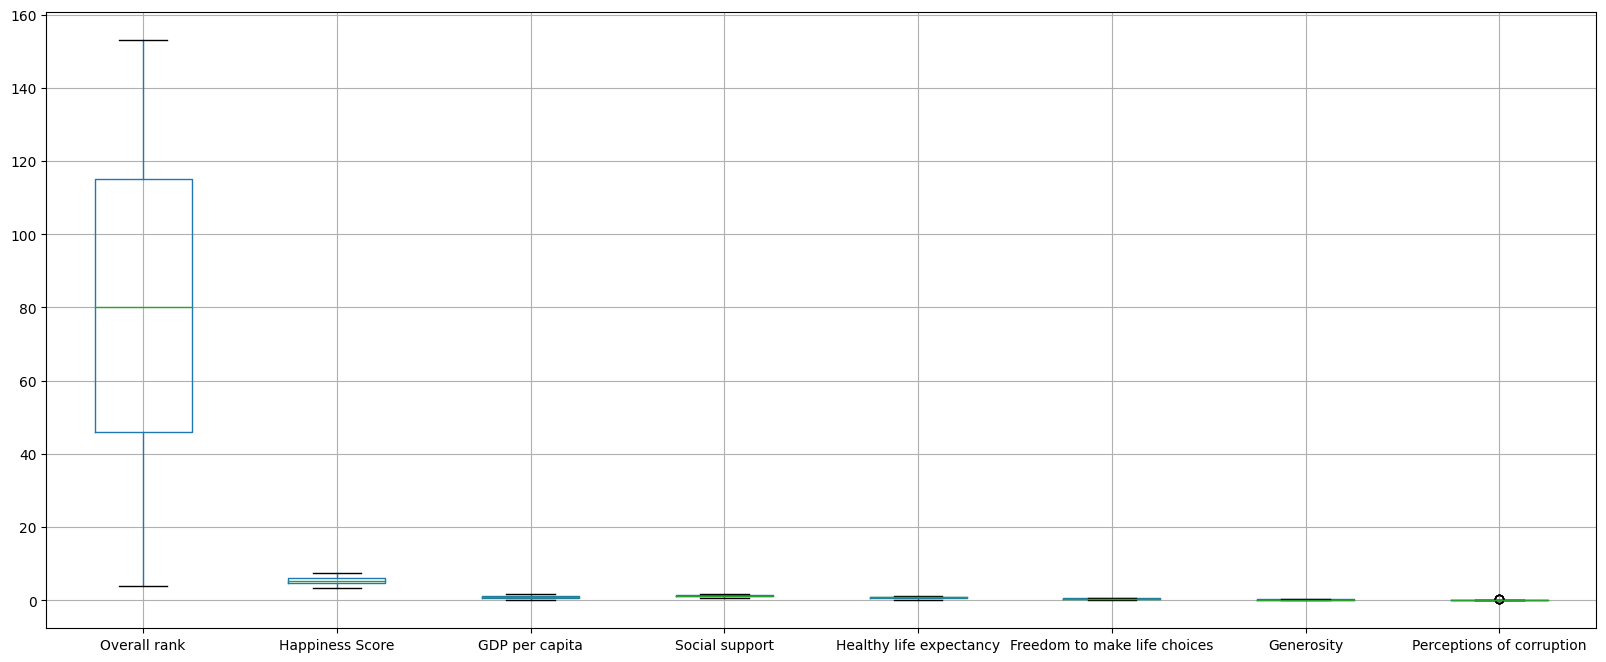

In [ ]:
def remove_outliers(df, column):
    sorted(df)
    Q1, Q3 = np.percentile(df[column], [25, 75])
    IQR = Q3 - Q1
    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)
    df = df[(df[column] > lower_range) & (df[column] < upper_range)]
    return df

df = remove_outliers(df, 'GDP per capita')
df = remove_outliers(df, 'Social support')
df = remove_outliers(df, 'Healthy life expectancy')
df = remove_outliers(df, 'Freedom to make life choices')
df = remove_outliers(df, 'Generosity')
df = remove_outliers(df, 'Perceptions of corruption')

# Check if there is any outliers

df.boxplot(figsize=(20, 8))
plt.show()

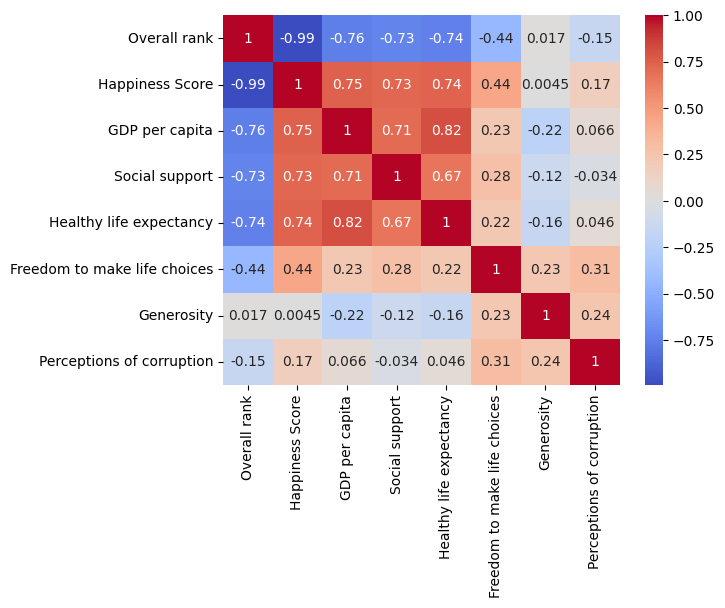

In [ ]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

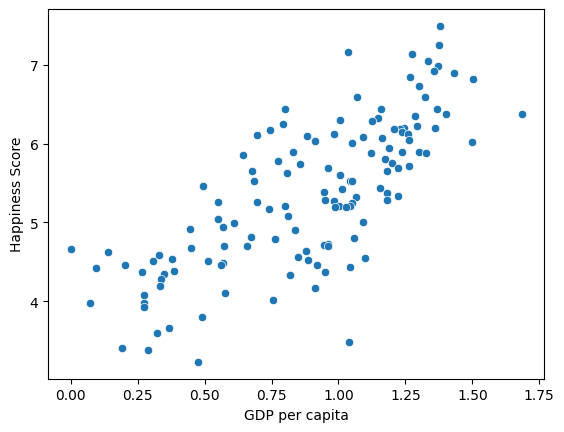

In [ ]:
sns.scatterplot(x = 'GDP per capita', y = 'Happiness Score', data = df)
plt.show()

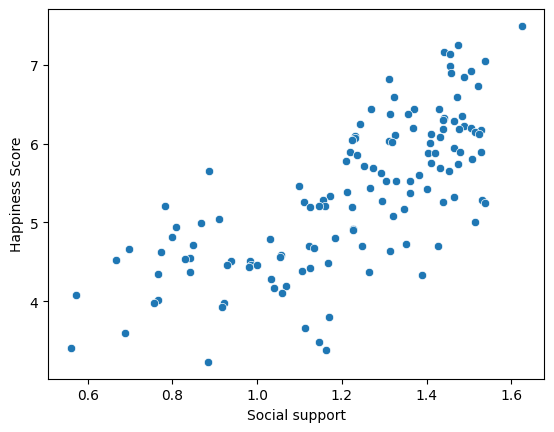

In [ ]:
sns.scatterplot(x = 'Social support', y = 'Happiness Score', data = df)
plt.show()

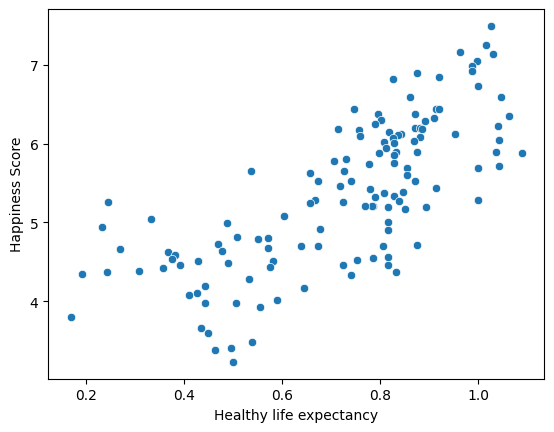

In [ ]:
sns.scatterplot(x = 'Healthy life expectancy', y = 'Happiness Score', data = df)
plt.show()

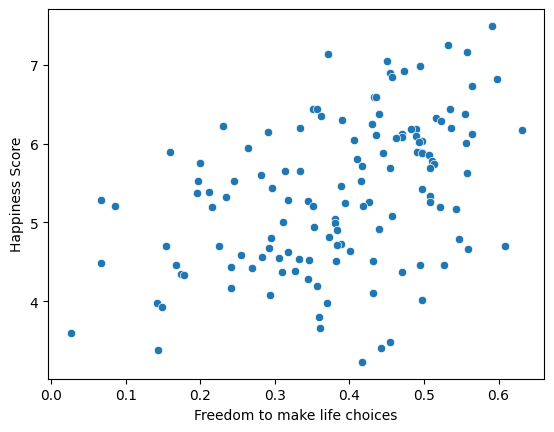

In [ ]:
sns.scatterplot(x = 'Freedom to make life choices', y = 'Happiness Score', data = df)
plt.show()

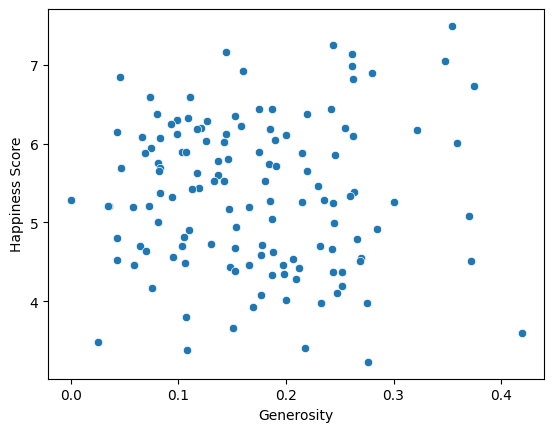

In [ ]:
sns.scatterplot(x = 'Generosity', y = 'Happiness Score', data = df)
plt.show()

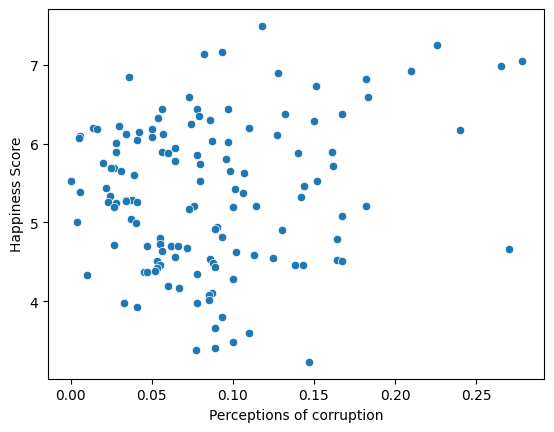

In [ ]:
sns.scatterplot(x = 'Perceptions of corruption', y = 'Happiness Score', data = df)
plt.show()

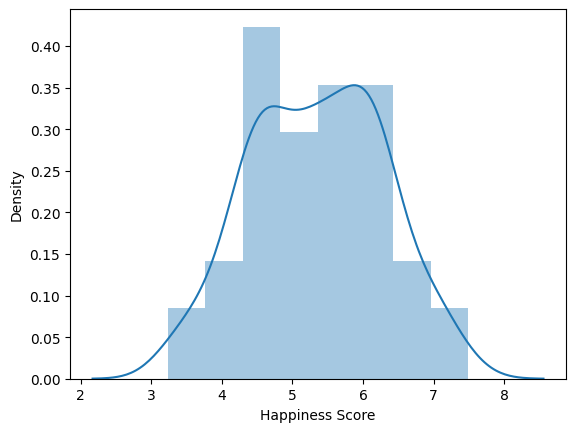

In [ ]:
sns.distplot(df['Happiness Score'])
plt.show()

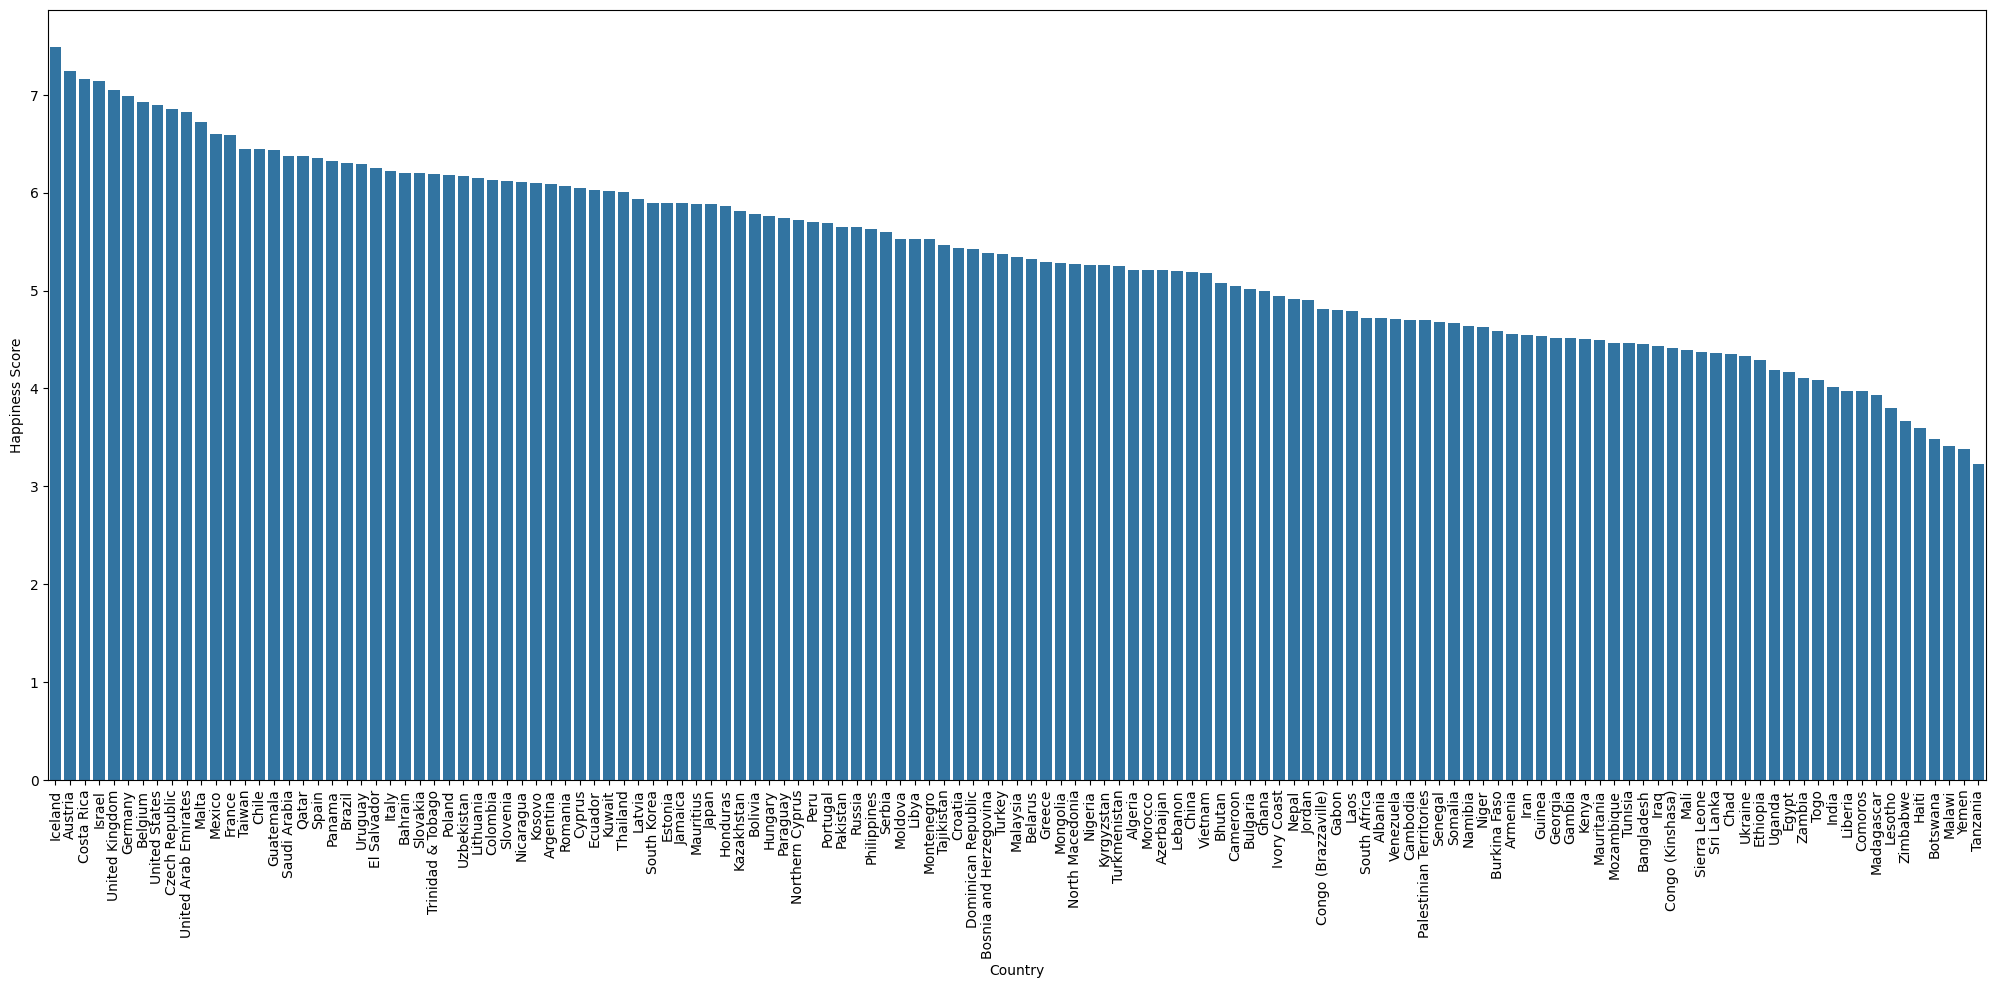

In [ ]:
plt.figure(figsize=(25, 10))
sns.barplot(x='Country', y='Happiness Score', data=df)
plt.xticks(rotation=90)
plt.show()

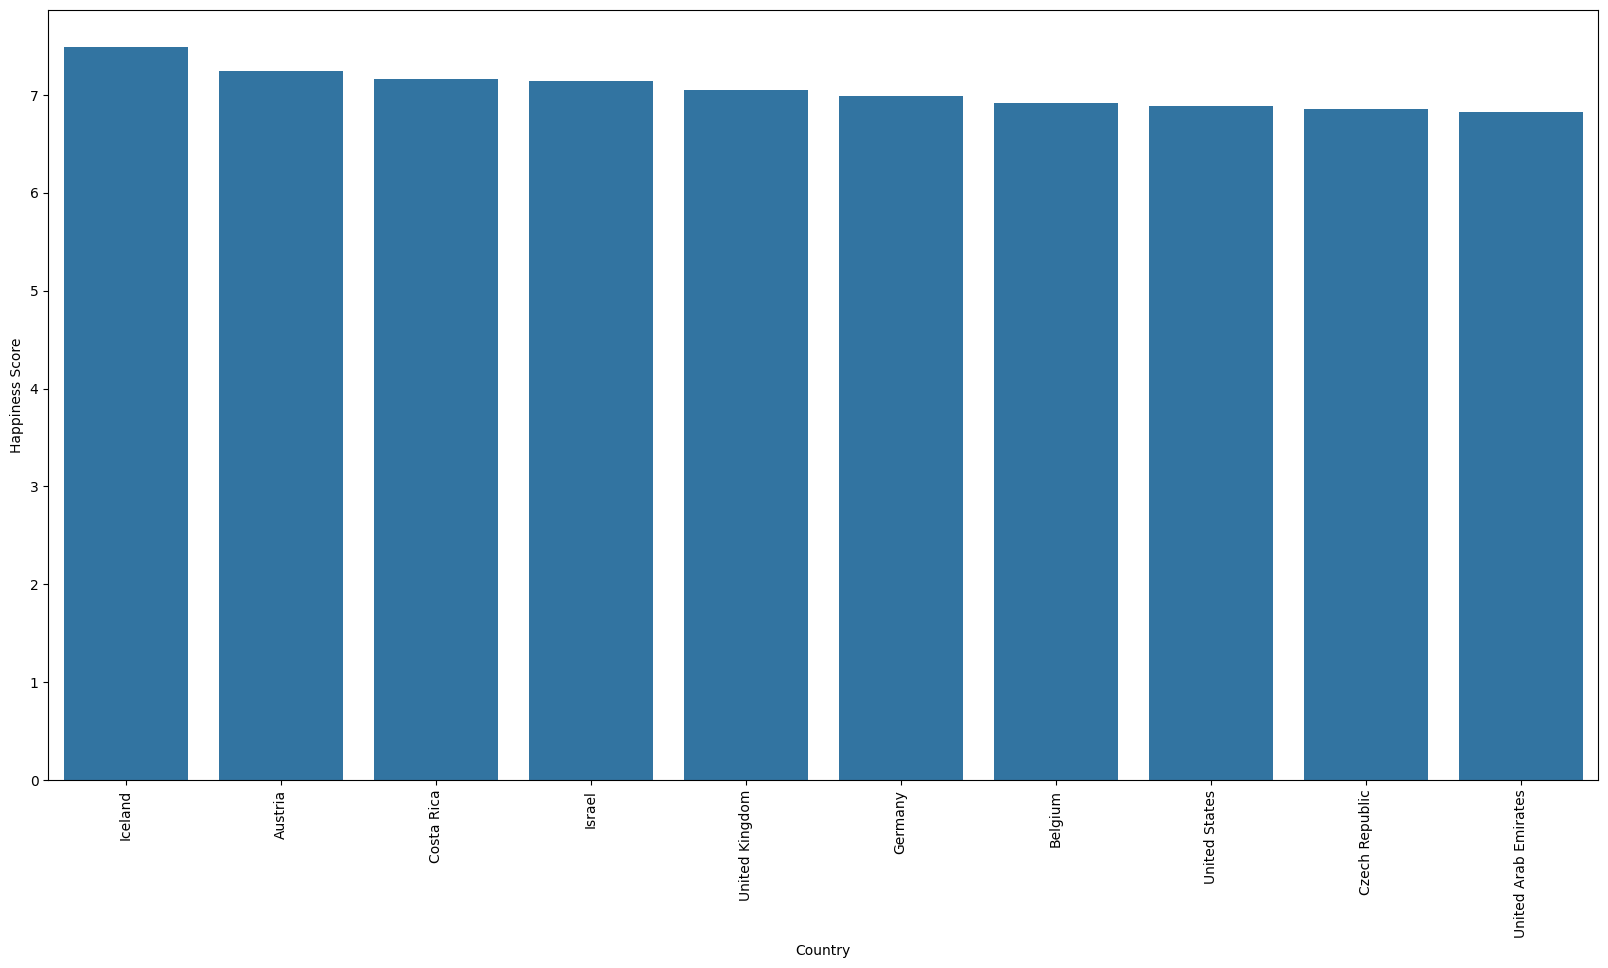

In [ ]:
top10 = df.sort_values(by = 'Happiness Score', ascending = False).head(10)
plt.figure(figsize=(20, 10))
sns.barplot(x = 'Country', y = 'Happiness Score', data = top10)
plt.xticks(rotation = 90)
plt.show()

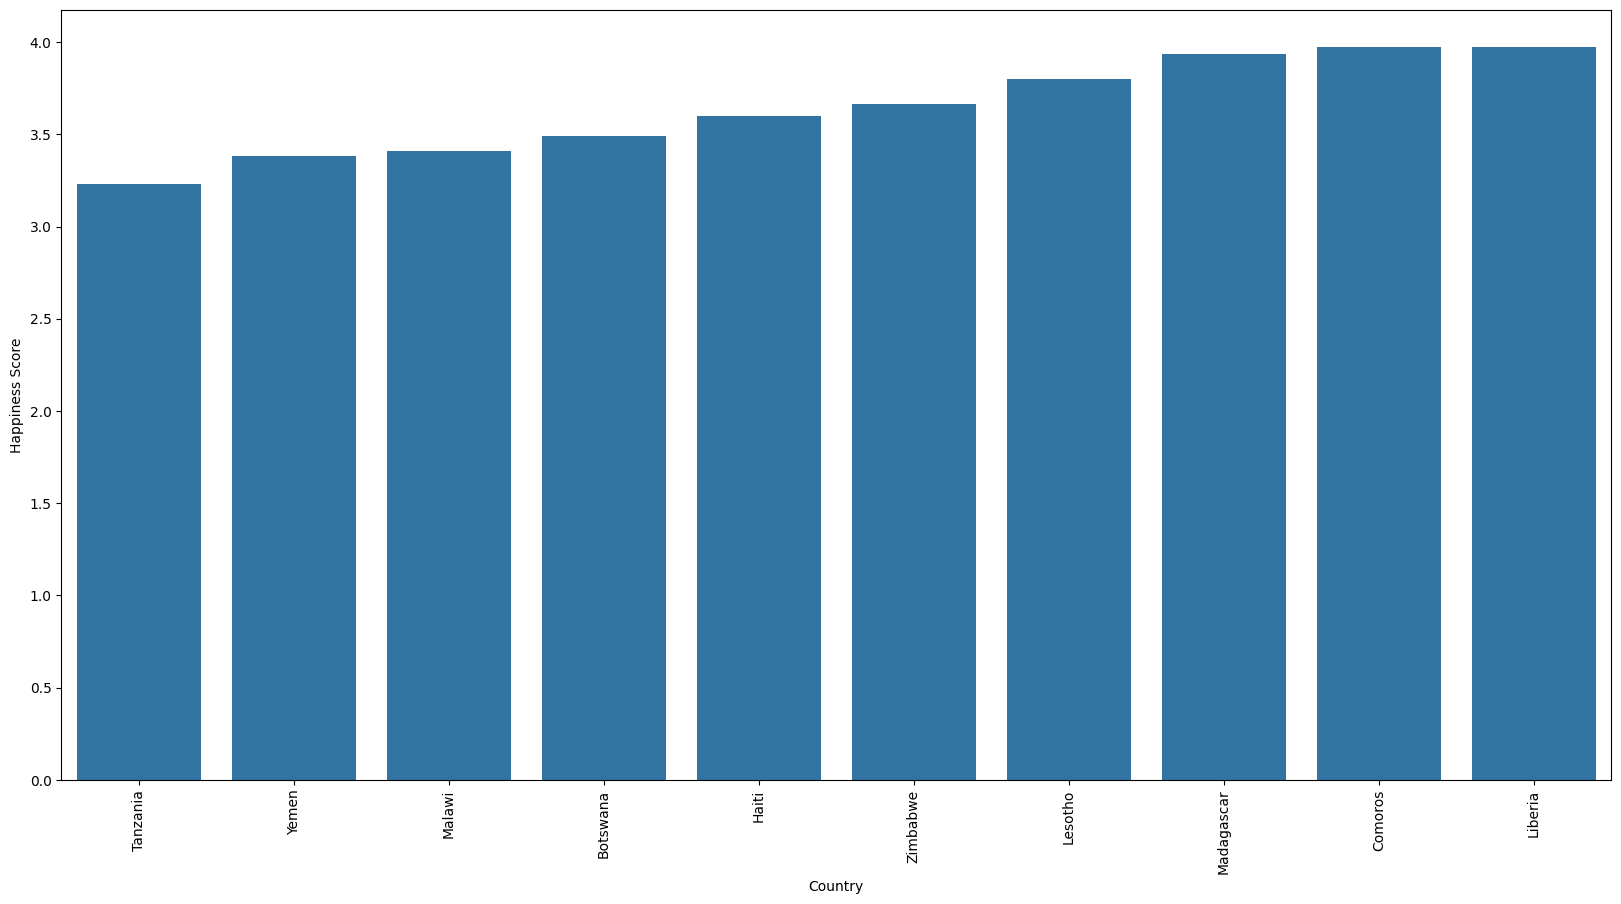

In [ ]:
bottom10 = df.sort_values(by = 'Happiness Score', ascending = True).head(10)
plt.figure(figsize=(20, 10))
sns.barplot(x = 'Country', y = 'Happiness Score', data = bottom10)
plt.xticks(rotation = 90)
plt.show()

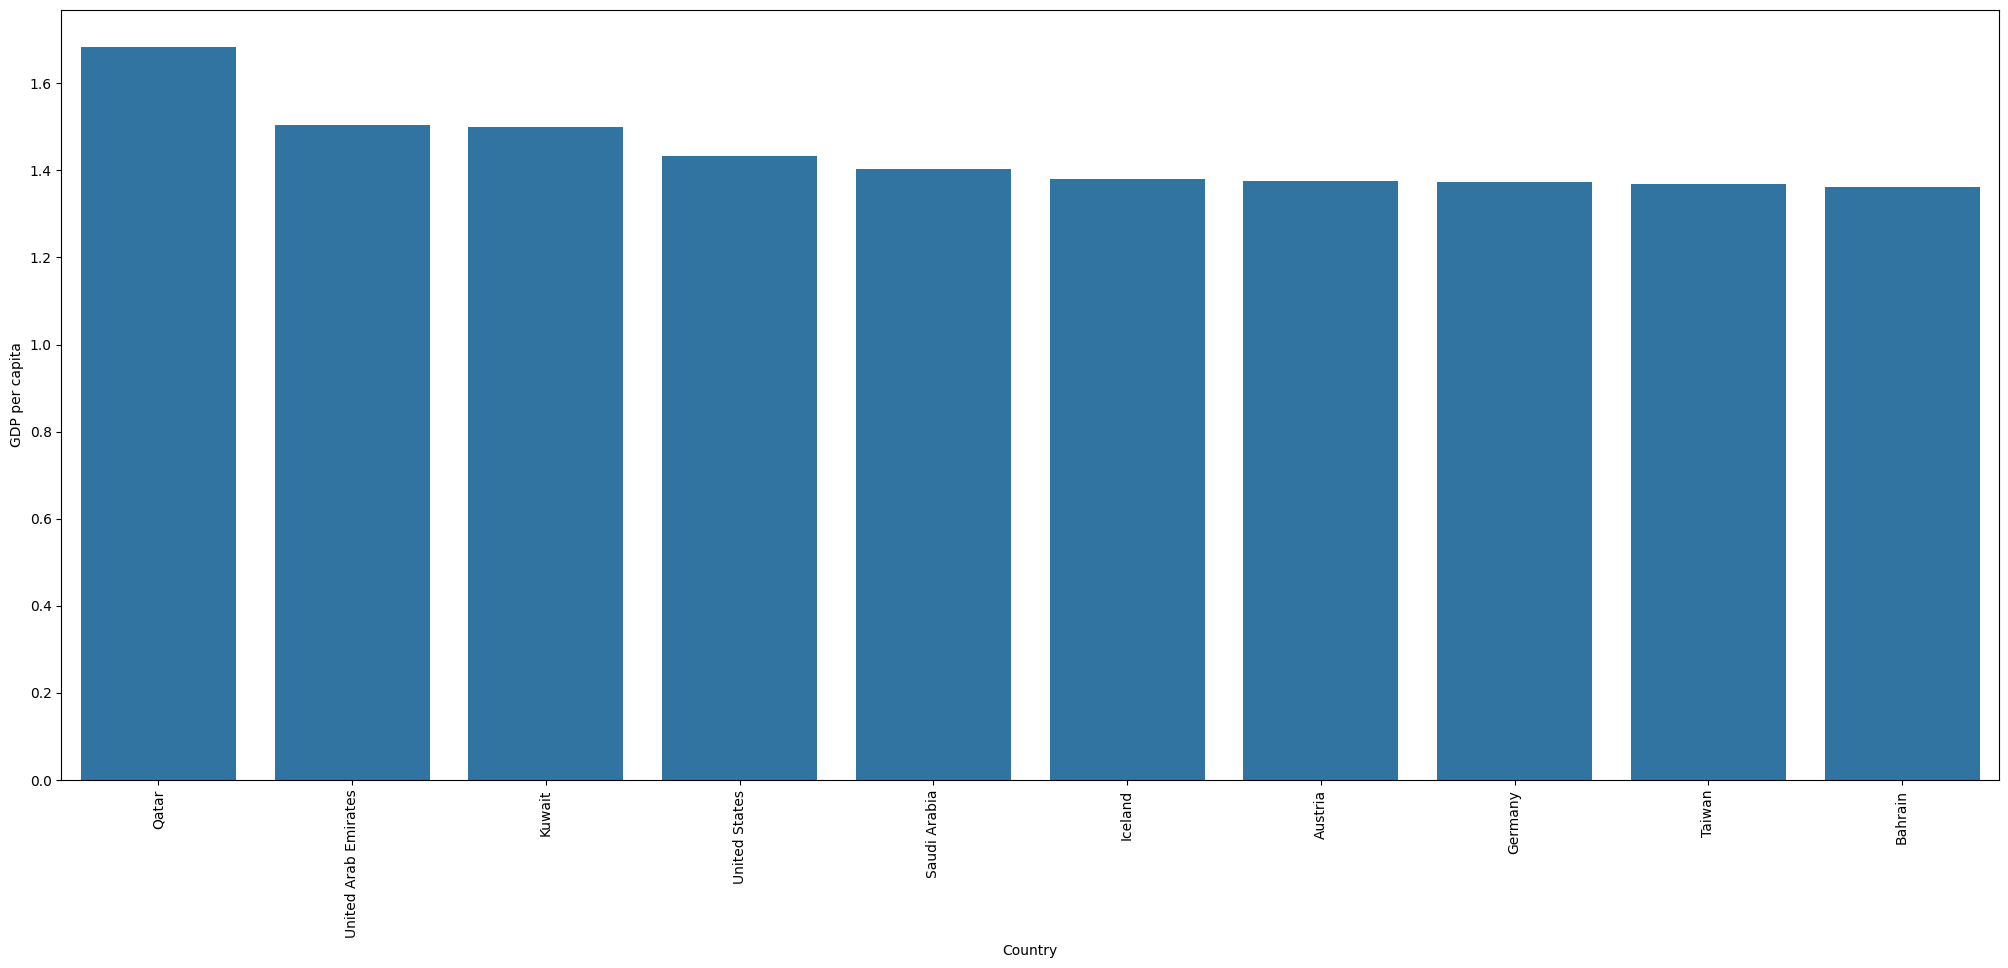

In [ ]:
top10_gdp = df.sort_values(by = 'GDP per capita', ascending = False).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'GDP per capita', data = top10_gdp)
plt.xticks(rotation = 90)
plt.show()

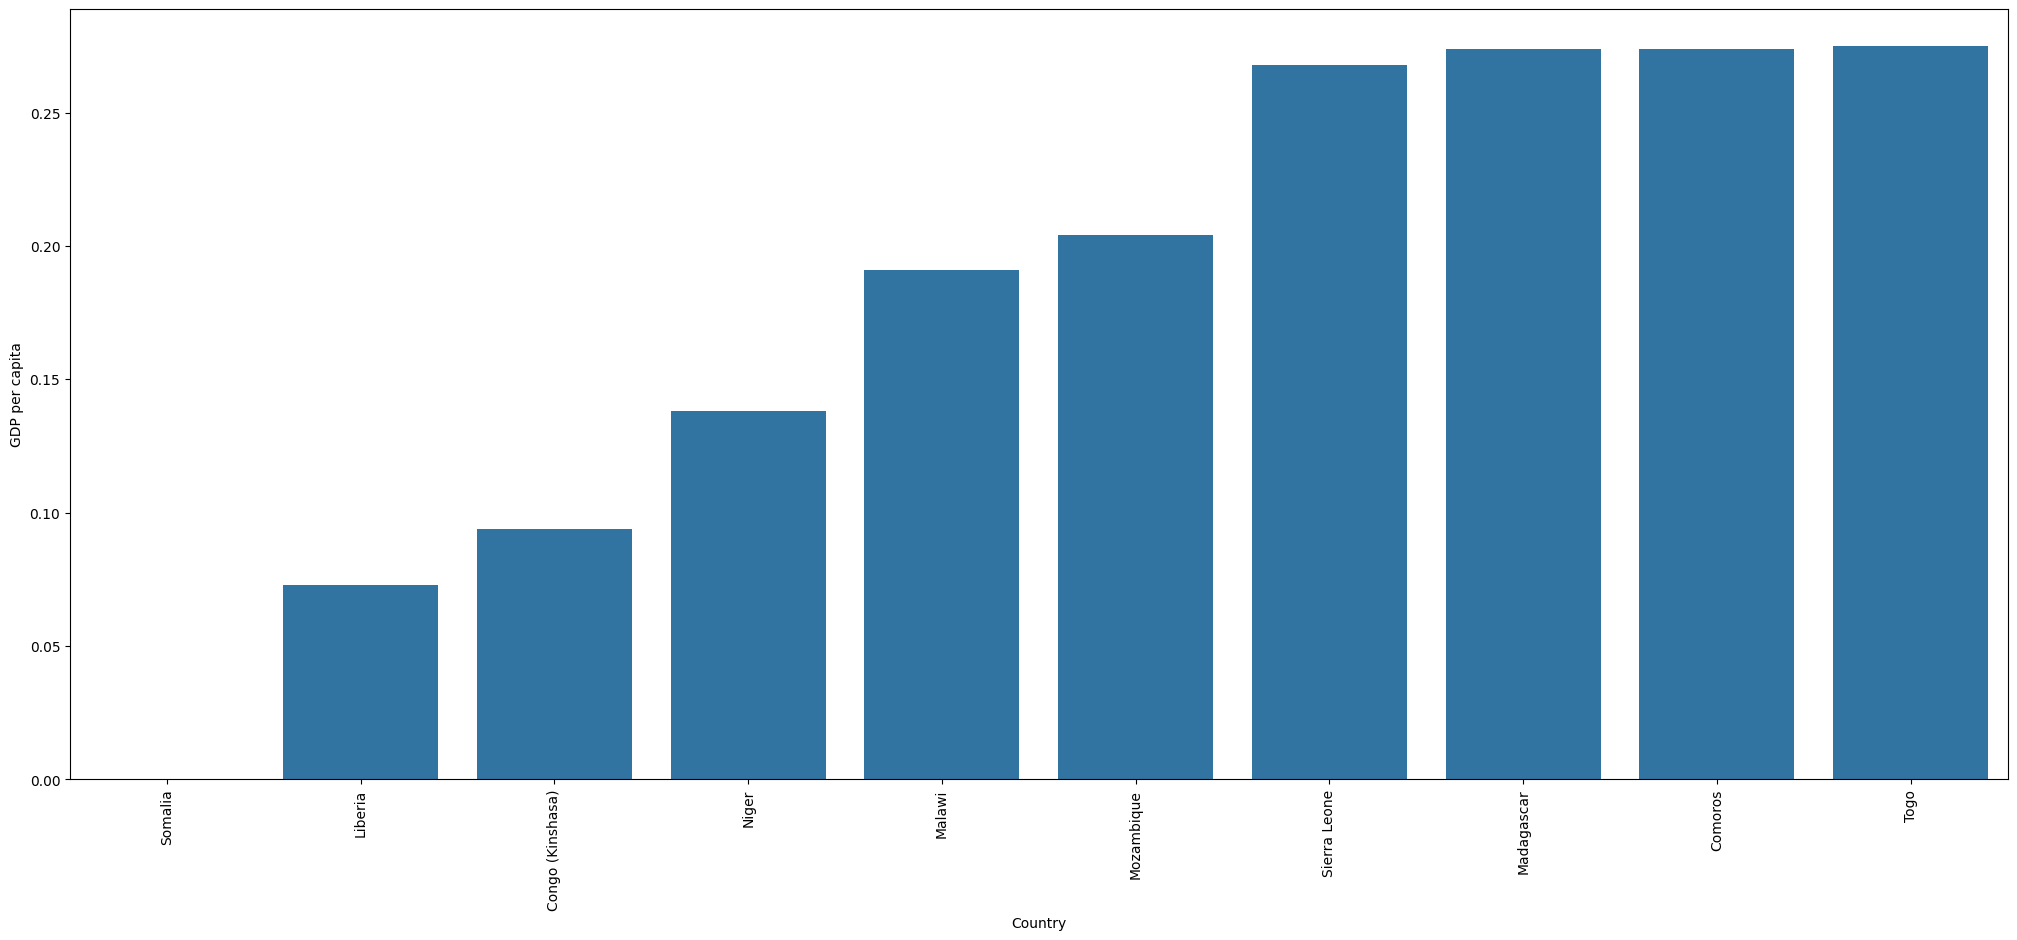

In [ ]:
bottom10_gdp = df.sort_values(by = 'GDP per capita', ascending = True).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'GDP per capita', data = bottom10_gdp)
plt.xticks(rotation = 90)
plt.show()

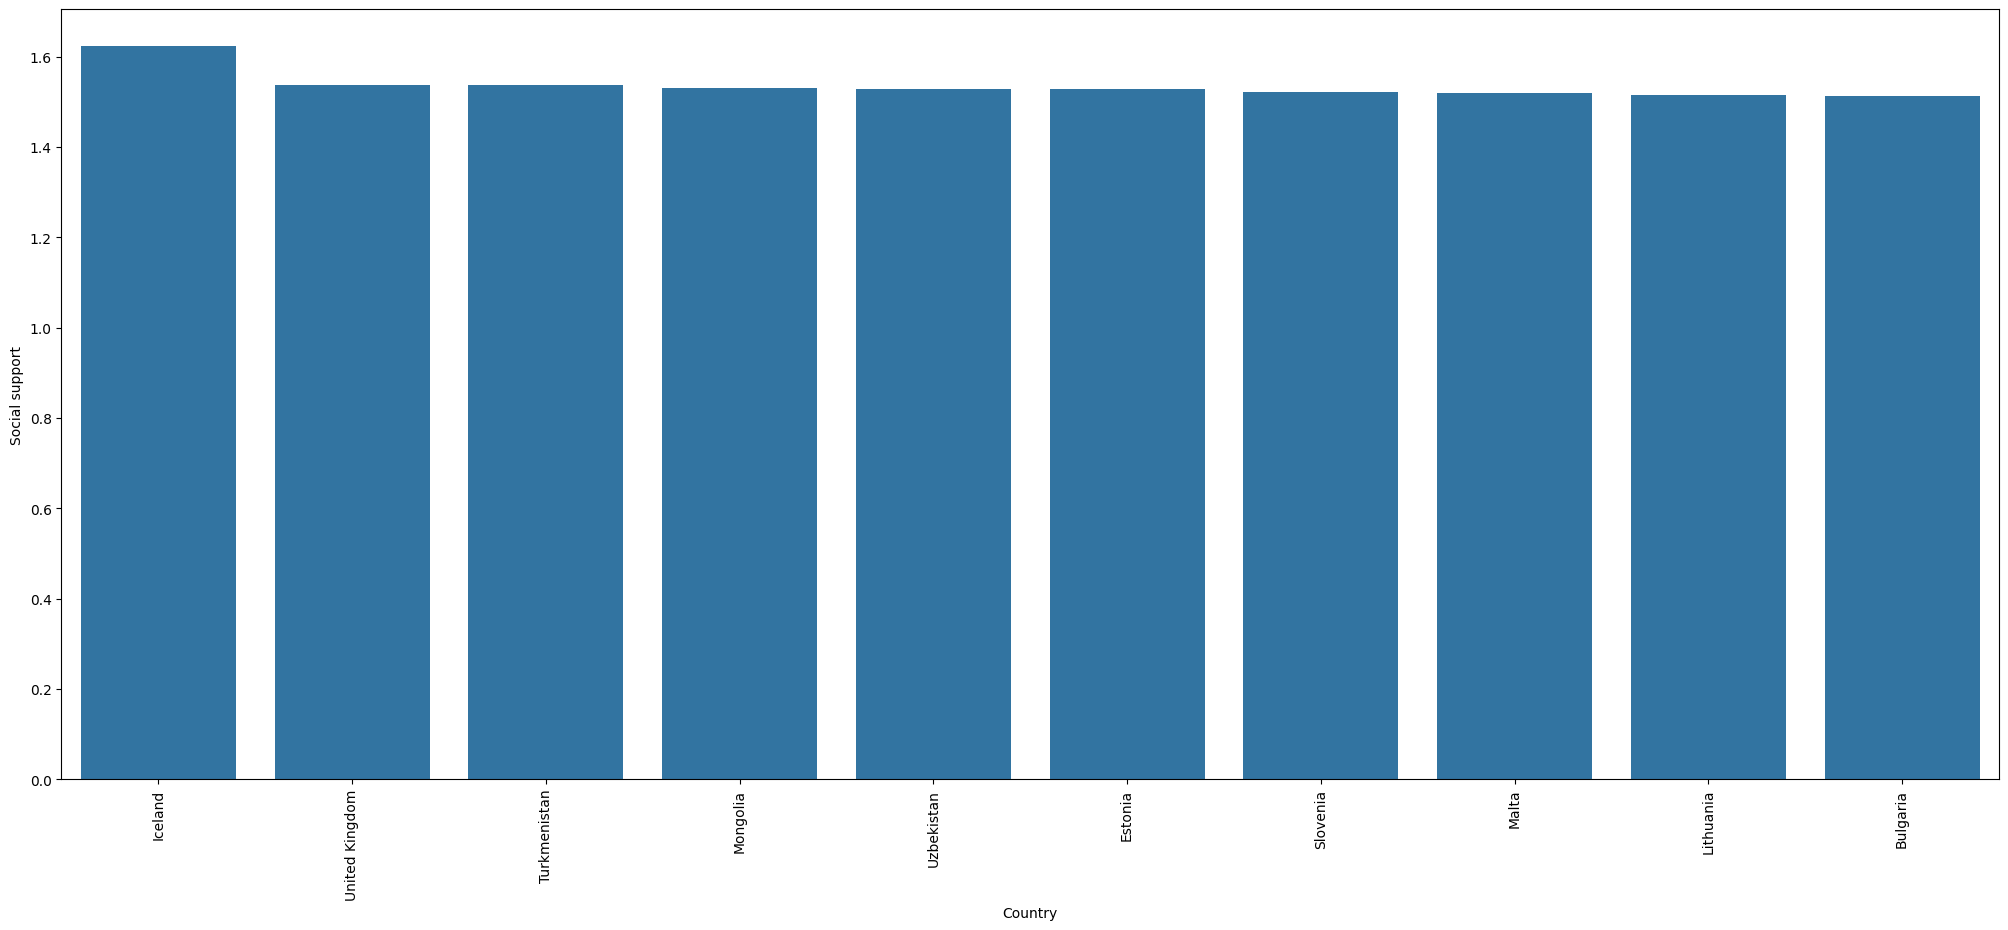

In [ ]:
top10_social = df.sort_values(by = 'Social support', ascending = False).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'Social support', data = top10_social)
plt.xticks(rotation = 90)
plt.show()

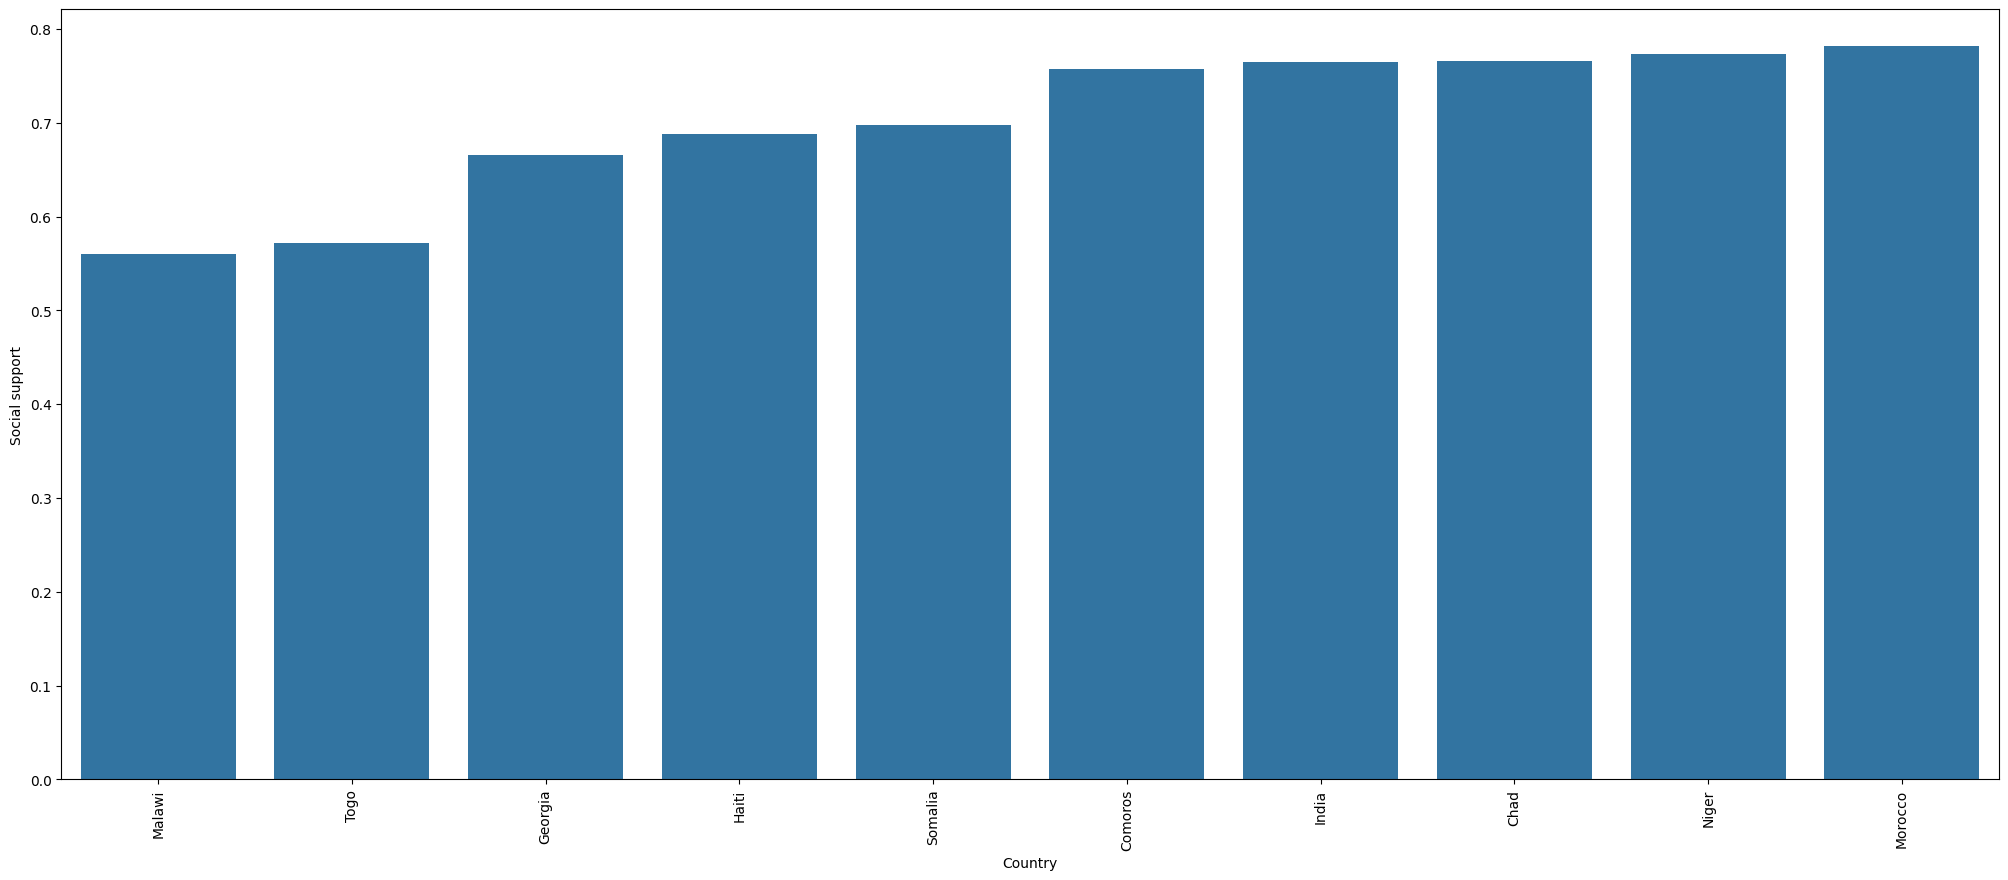

In [ ]:
bottom10_social = df.sort_values(by = 'Social support', ascending = True).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'Social support', data = bottom10_social)
plt.xticks(rotation = 90)
plt.show()

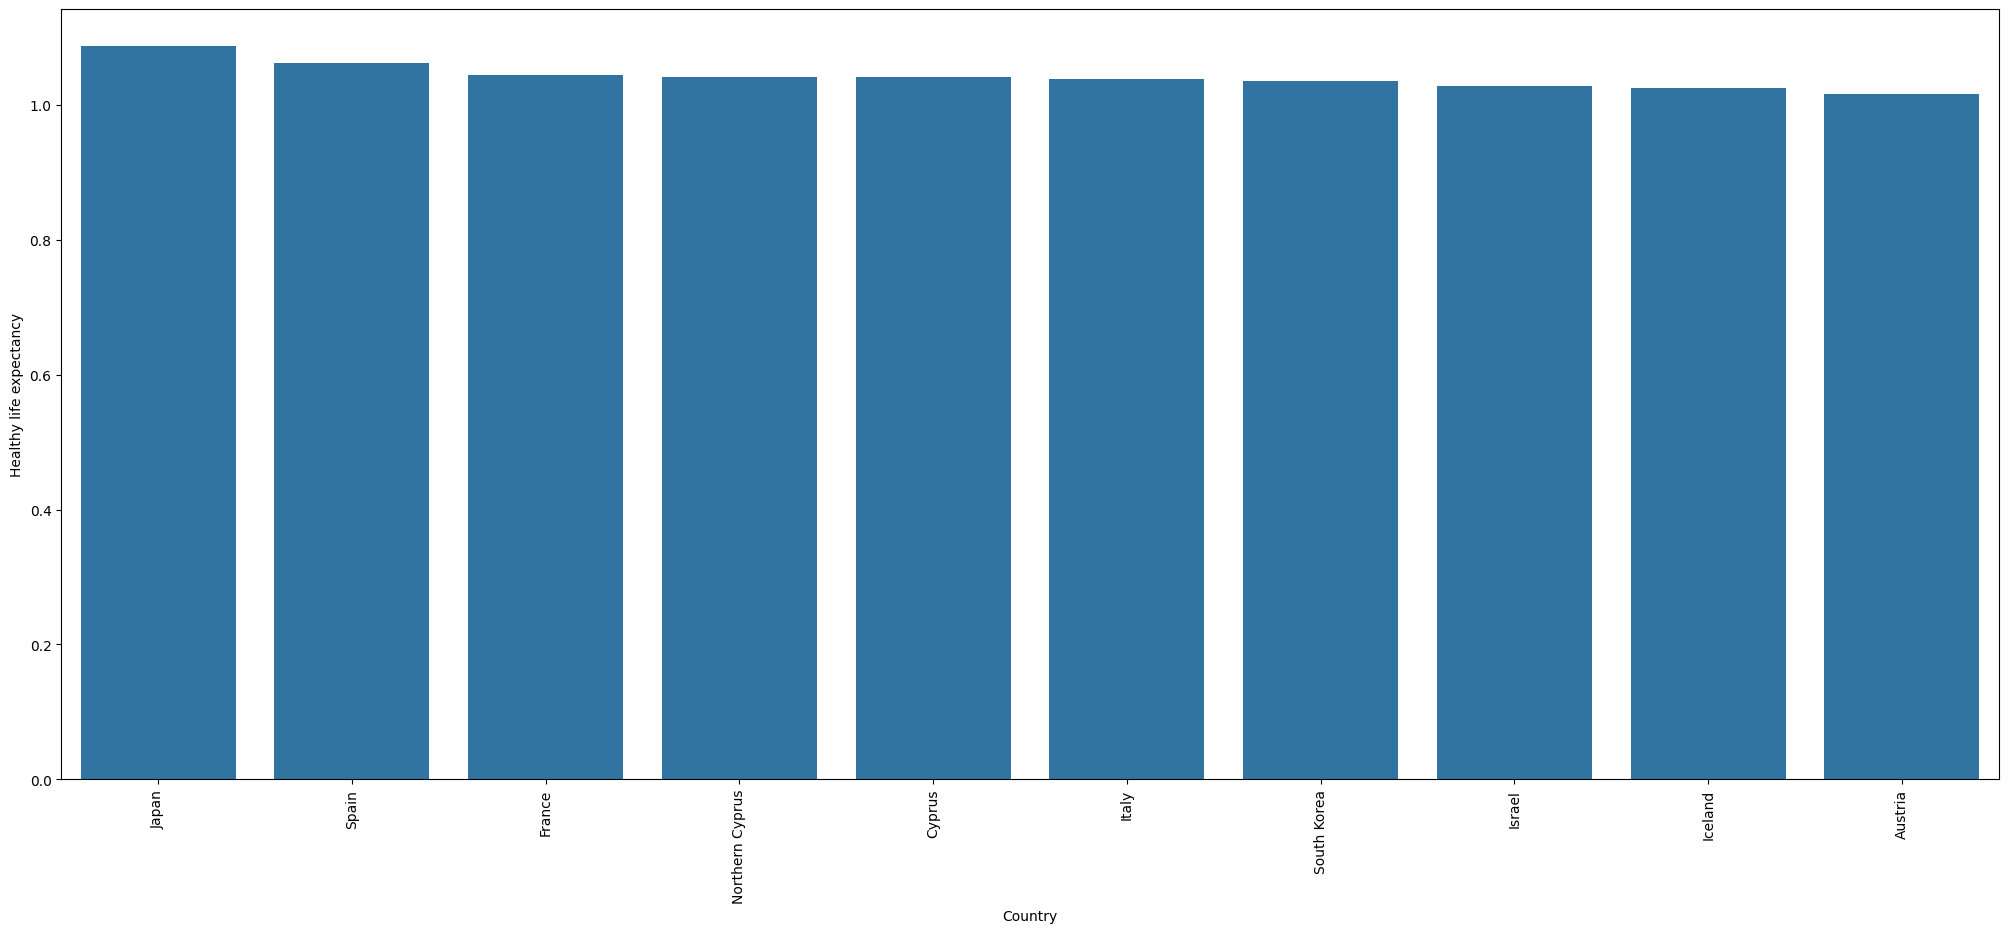

In [ ]:
top10_health = df.sort_values(by = 'Healthy life expectancy', ascending = False).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'Healthy life expectancy', data = top10_health)
plt.xticks(rotation = 90)
plt.show()

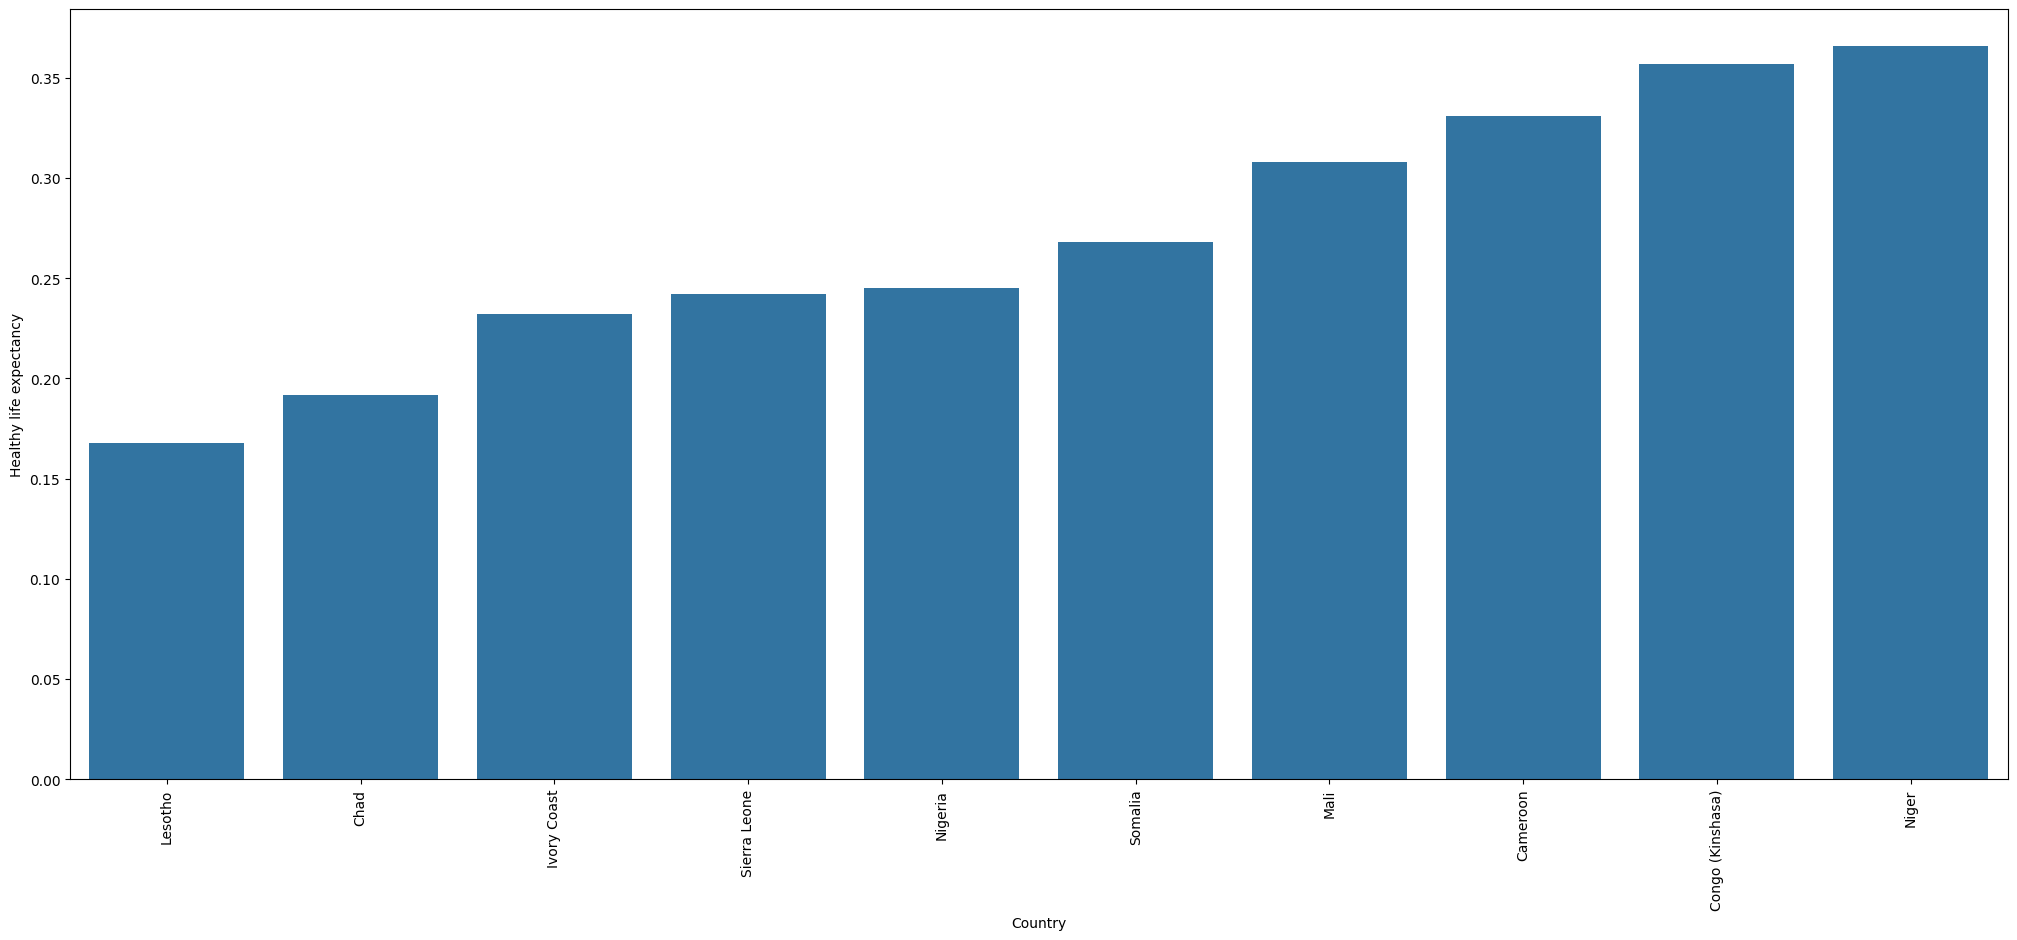

In [ ]:
bottom10_health = df.sort_values(by = 'Healthy life expectancy', ascending = True).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'Healthy life expectancy', data = bottom10_health)
plt.xticks(rotation = 90)
plt.show()

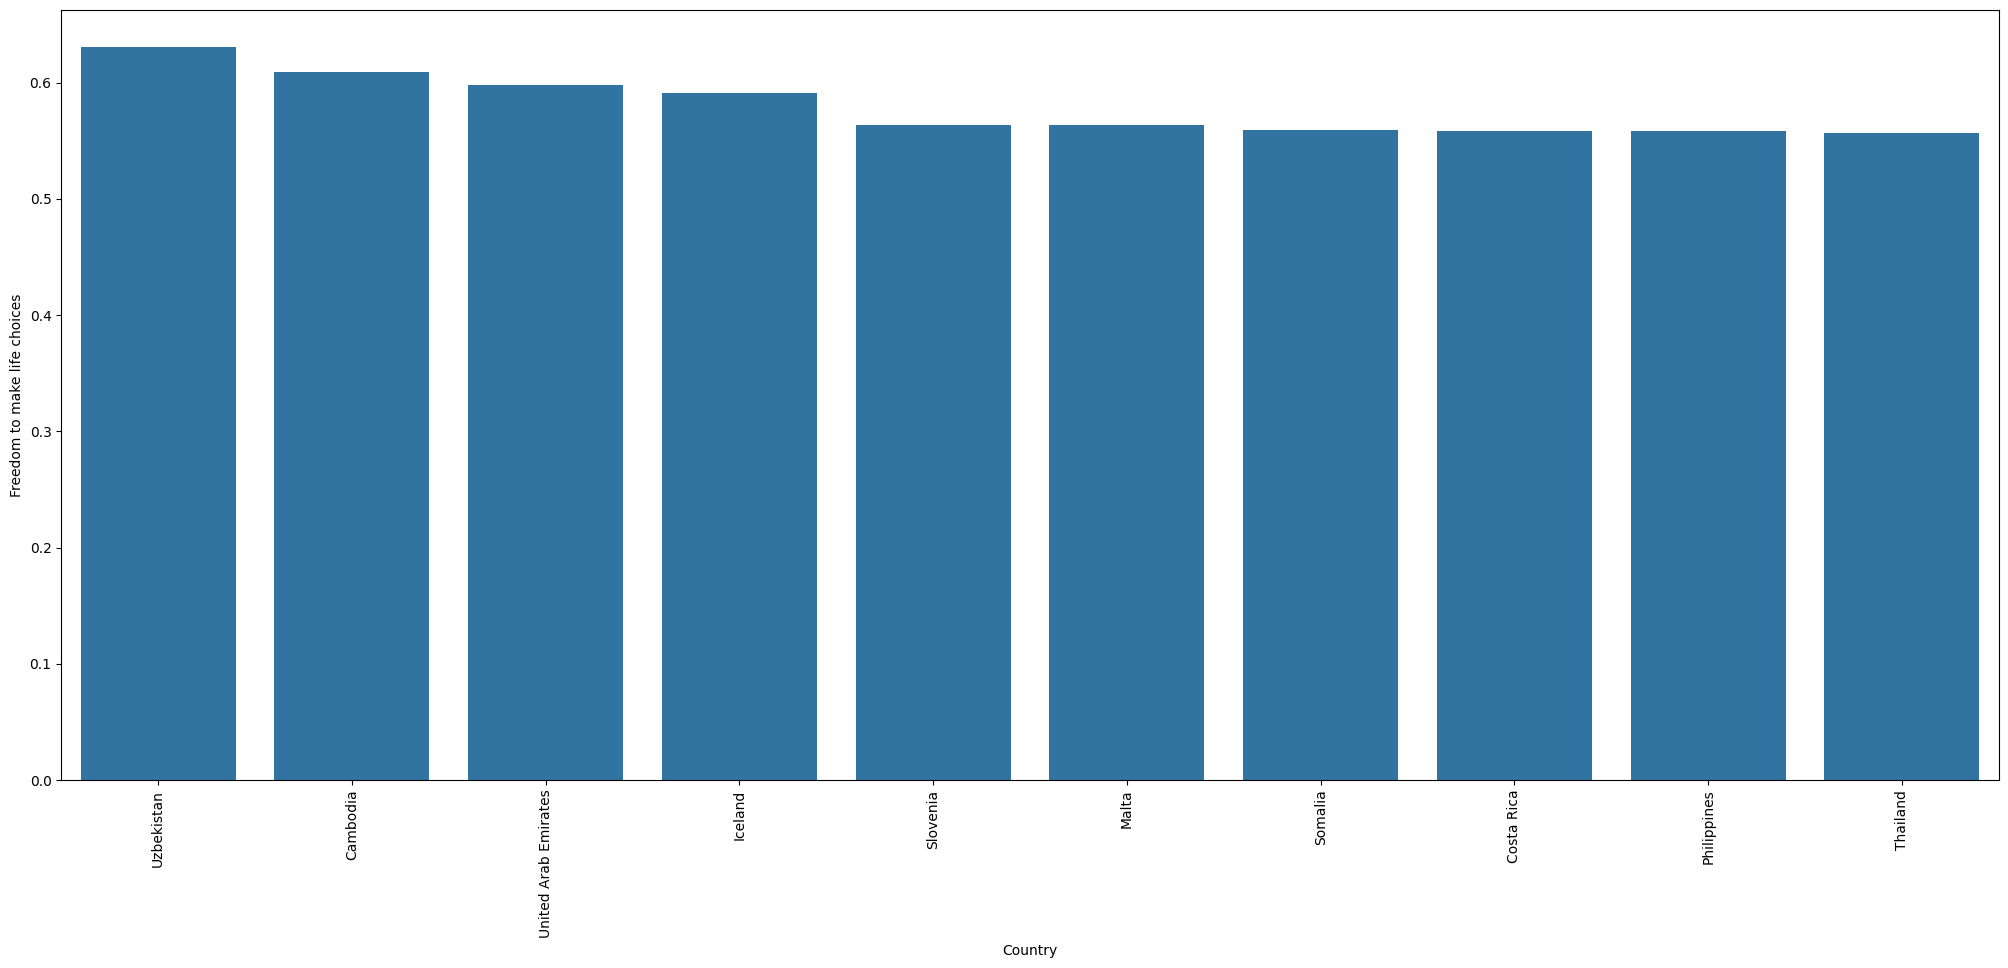

In [ ]:
top10_freedom = df.sort_values(by = 'Freedom to make life choices', ascending = False).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'Freedom to make life choices', data = top10_freedom)
plt.xticks(rotation = 90)
plt.show()

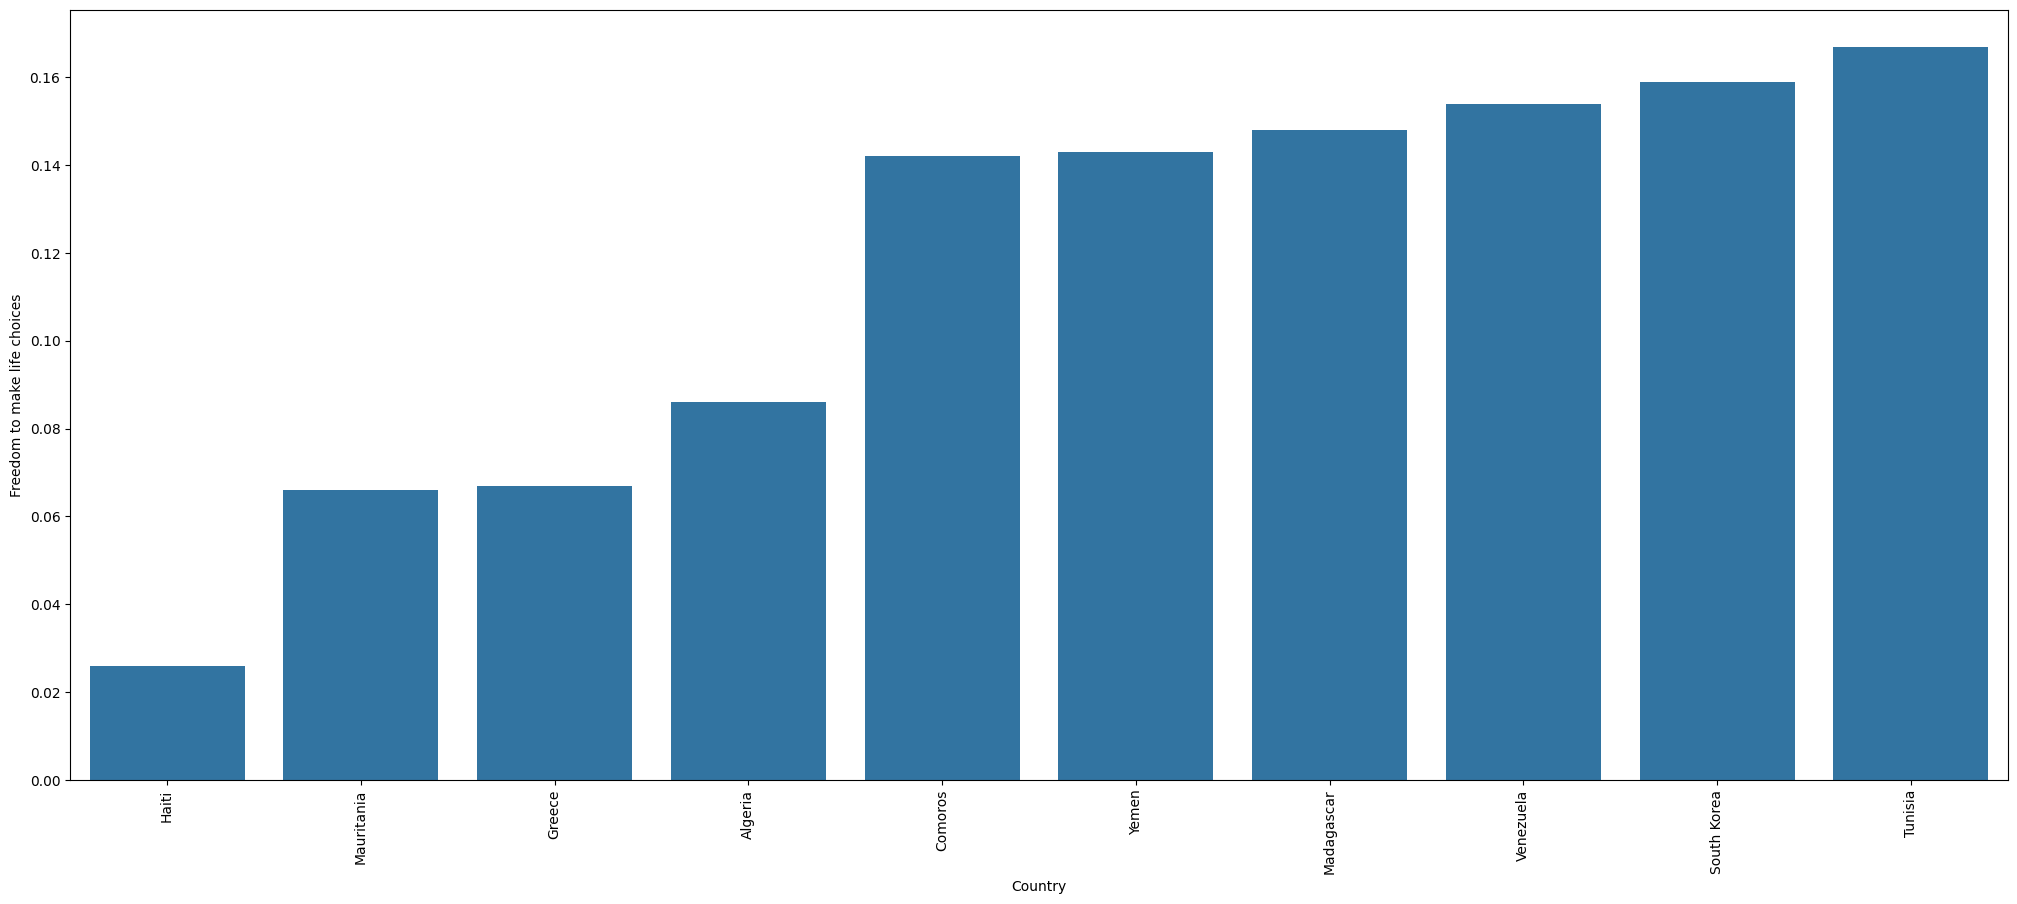

In [ ]:
bottom10_freedom = df.sort_values(by = 'Freedom to make life choices', ascending = True).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'Freedom to make life choices', data = bottom10_freedom)
plt.xticks(rotation = 90)
plt.show()

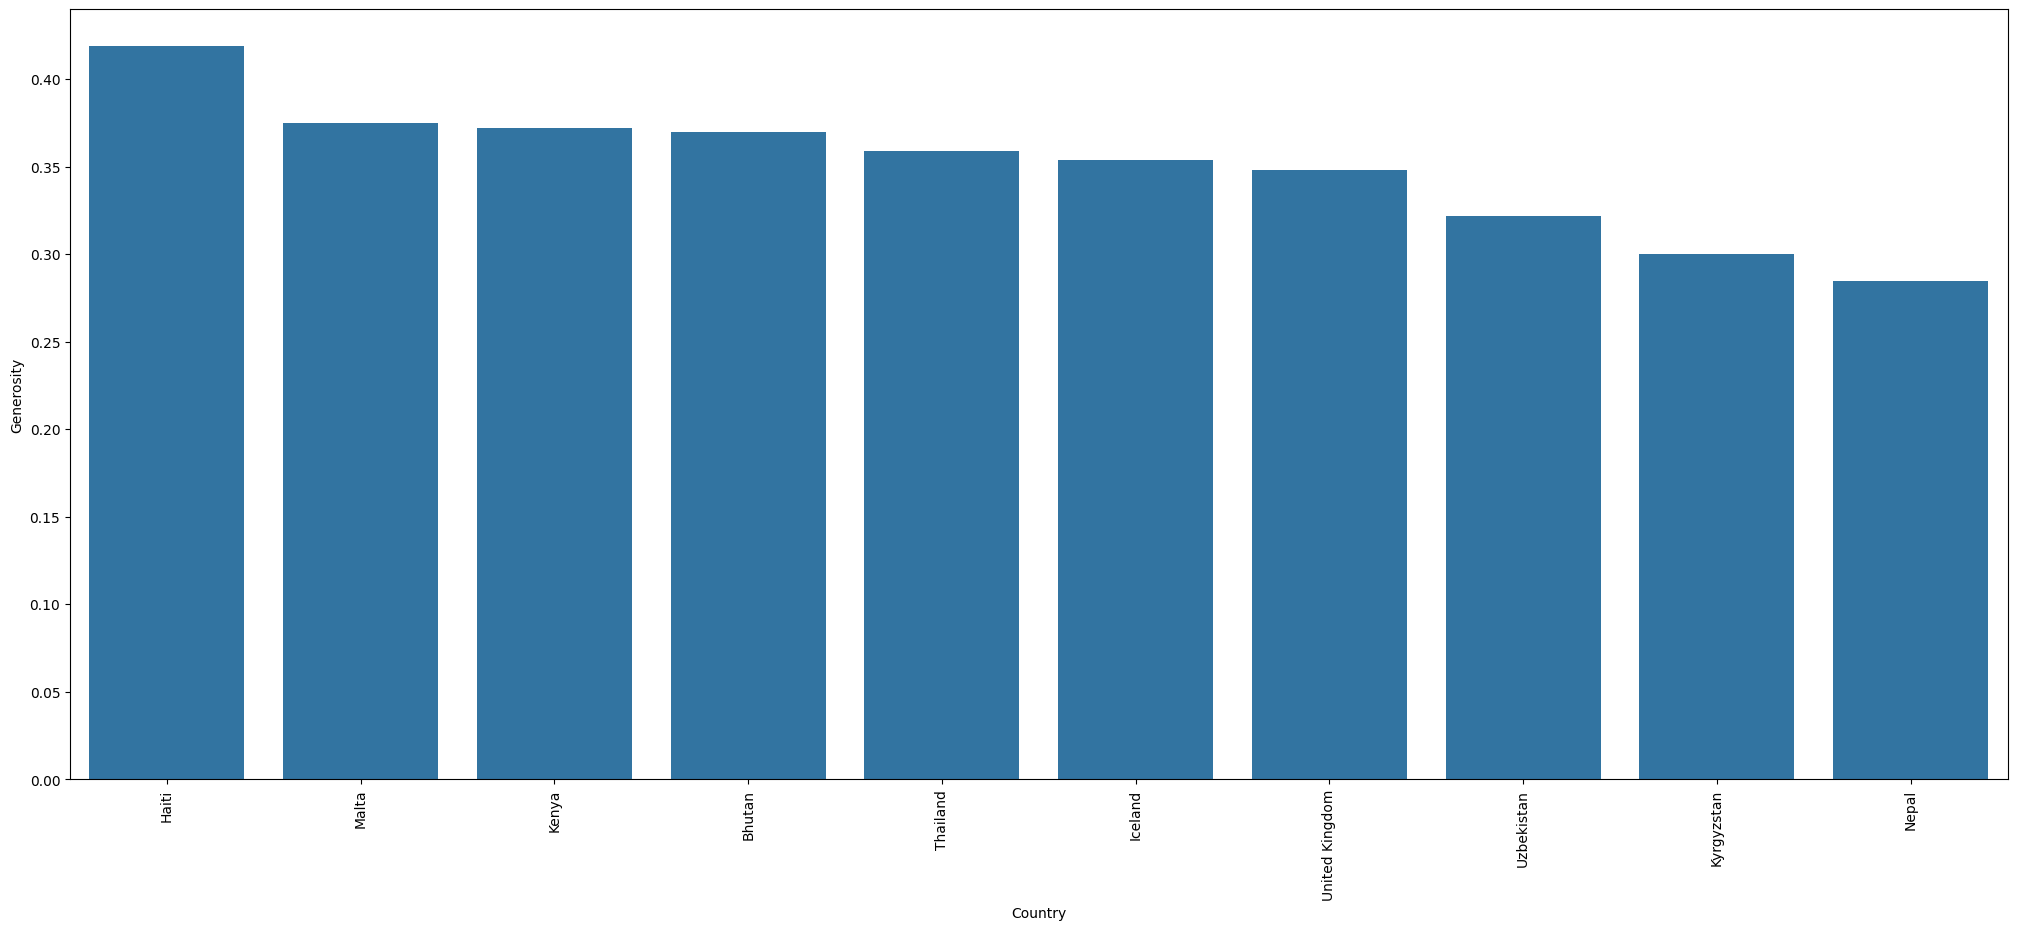

In [ ]:
top10_generosity = df.sort_values(by = 'Generosity', ascending = False).head(10)
plt.figure(figsize=(25, 10))
sns.barplot(x = 'Country', y = 'Generosity', data = top10_generosity)
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Splitting the data into features and target
X = df.drop(['Country', 'Happiness Score'], axis=1)
y = df['Happiness Score']

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_score = lr.score(X_test, y_test)
print('Linear Regression Score: ', lr_score)

# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_score = dt.score(X_test, y_test)
print('Decision Tree Score: ', dt_score)

# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_score = rf.score(X_test, y_test)
print('Random Forest Score: ', rf_score)

# XGBoost
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_score = xgb.score(X_test, y_test)
print('XGBoost Score: ', xgb_score)

# RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_score = rf.score(X_test, y_test)
print('RandomForestRegressor Score: ', rf_score)

# GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_score = gb.score(X_test, y_test)
print('GradientBoostingRegressor Score: ', gb_score)

# AdaBoostRegressor
ada = AdaBoostRegressor()
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
ada_score = ada.score(X_test, y_test)
print('AdaBoostRegressor Score: ', ada_score)

# KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_score = knn.score(X_test, y_test)
print('KNeighborsRegressor Score: ', knn_score)

Linear Regression Score:  0.9831111319940309
Decision Tree Score:  0.9907665576148152
Random Forest Score:  0.9976051420558738
XGBoost Score:  0.9977512169006937
RandomForestRegressor Score:  0.998266012060333
GradientBoostingRegressor Score:  0.99861054124716
AdaBoostRegressor Score:  0.9966418533336373
KNeighborsRegressor Score:  0.8224142658559572


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [ ]:
# Linear Regression
print('Linear Regression')
print('Mean Squared Error:', mean_squared_error(y_test, lr_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, lr_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, lr_pred))
print('R2 Score:', r2_score(y_test, lr_pred))

print('*************************')


# Decision Tree
print('Decision Tree')
print('Mean Squared Error:', mean_squared_error(y_test, dt_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, dt_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, dt_pred))
print('R2 Score:', r2_score(y_test, dt_pred))

print('*************************')

# Random Forest
print('Random Forest')
print('Mean Squared Error:', mean_squared_error(y_test, rf_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, rf_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, rf_pred))
print('R2 Score:', r2_score(y_test, rf_pred))

print('*************************')

# XGBoost
print('XGBoost')
print('Mean Squared Error:', mean_squared_error(y_test, xgb_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, xgb_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, xgb_pred))
print('R2 Score:', r2_score(y_test, xgb_pred))

print('*************************')  # Add a newline between the output for the two models

# RandomForestRegressor
print('RandomForestRegressor')
print('Mean Squared Error:', mean_squared_error(y_test, rf_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, rf_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, rf_pred))
print('R2 Score:', r2_score(y_test, rf_pred))

print('*************************')

# GradientBoostingRegressor
print('GradientBoostingRegressor')
print('Mean Squared Error:', mean_squared_error(y_test, gb_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, gb_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, gb_pred))
print('R2 Score:', r2_score(y_test, gb_pred))

print('*************************')

# AdaBoostRegressor
print('AdaBoostRegressor')
print('Mean Squared Error:', mean_squared_error(y_test, ada_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, ada_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, ada_pred))
print('R2 Score:', r2_score(y_test, ada_pred))

print('*************************')

# KNeighborsRegressor
print('KNeighborsRegressor')
print('Mean Squared Error:', mean_squared_error(y_test, knn_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, knn_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, knn_pred))
print('R2 Score:', r2_score(y_test, knn_pred))

Linear Regression
Mean Squared Error: 0.015631807458803246
Root Mean Squared Error: 0.12502722687000317
Mean Absolute Error: 0.08998233382131028
R2 Score: 0.9831111319940309
*************************
Decision Tree
Mean Squared Error: 0.008546185185185183
Root Mean Squared Error: 0.09244557958704777
Mean Absolute Error: 0.062481481481481374
R2 Score: 0.9907665576148152
*************************
Random Forest
Mean Squared Error: 0.0016049249481481218
Root Mean Squared Error: 0.04006151455135117
Mean Absolute Error: 0.028272592592592776
R2 Score: 0.998266012060333
*************************
XGBoost
Mean Squared Error: 0.002081403230372956
Root Mean Squared Error: 0.04562239834086932
Mean Absolute Error: 0.03452132458157005
R2 Score: 0.9977512169006937
*************************
RandomForestRegressor
Mean Squared Error: 0.0016049249481481218
Root Mean Squared Error: 0.04006151455135117
Mean Absolute Error: 0.028272592592592776
R2 Score: 0.998266012060333
*************************
GradientBoo

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:

# Random Forest
rf_params = {"max_depth": [3, 5, 8, None],
                "max_features": [3, 5, 10],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 3, 5, 10],
                "bootstrap": [True, False],
                "n_estimators": [100, 500, 1000],
                "random_state": [42]}
rf_cv_model = GridSearchCV(rf, rf_params, cv=5, n_jobs=-1, verbose=2)
rf_cv_model.fit(X_train, y_train)
print("Best Parameters: " + str(rf_cv_model.best_params_))

# GradientBoostingRegressor
gb_params = {"learning_rate": [0.01, 0.1, 0.05],
                "max_depth": [3, 5, 8],
                "max_features": [3, 5, 10],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 3, 5, 10],
                "n_estimators": [100, 500, 1000],
                "subsample": [1, 0.5, 0.75],
                "random_state": [42]}
gb_cv_model = GridSearchCV(gb, gb_params, cv=5, n_jobs=-1, verbose=2)
gb_cv_model.fit(X_train, y_train)
print("Best Parameters: " + str(gb_cv_model.best_params_))

# AdaBoostRegressor
ada_params = {"learning_rate": [0.01, 0.1, 0.05],
                "n_estimators": [100, 500, 1000],
                "random_state": [42]}
ada_cv_model = GridSearchCV(ada, ada_params, cv=5, n_jobs=-1, verbose=2)
ada_cv_model.fit(X_train, y_train)
print("Best Parameters: " + str(ada_cv_model.best_params_))

# KNeighborsRegressor
knn_params = {"n_neighbors": np.arange(1, 50)}
knn_cv_model = GridSearchCV(knn, knn_params, cv=5, n_jobs=-1, verbose=2)
knn_cv_model.fit(X_train, y_train)
print("Best Parameters: " + str(knn_cv_model.best_params_))

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
Best Parameters: {'bootstrap': True, 'max_depth': 8, 'max_features': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000, 'random_state': 42}
Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 1000, 'random_state': 42, 'subsample': 0.75}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 500, 'random_state': 42}
Fitting 5 folds for each of 49 candidates, totalling 245 fits
Best Parameters: {'n_neighbors': 5}


In [ ]:
models = [
    RandomForestRegressor(),
    GradientBoostingRegressor(),
    AdaBoostRegressor(),
    KNeighborsRegressor()
]

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(model)
    print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
    print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred)))
    print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
    print('R2 Score:', r2_score(y_test, y_pred))
    print('---------------------------------------------------')

RandomForestRegressor()
Mean Squared Error: 0.002875990188888838
Root Mean Squared Error: 0.053628259237913346
Mean Absolute Error: 0.03381740740740757
R2 Score: 0.9968927317704869
---------------------------------------------------
GradientBoostingRegressor()
Mean Squared Error: 0.0016482354434131429
Root Mean Squared Error: 0.040598466022907106
Mean Absolute Error: 0.0223031327068561
R2 Score: 0.9982192186719336
---------------------------------------------------
AdaBoostRegressor()
Mean Squared Error: 0.0013385146371654654
Root Mean Squared Error: 0.036585716299745524
Mean Absolute Error: 0.027507477867690273
R2 Score: 0.9985538462464612
---------------------------------------------------
KNeighborsRegressor()
Mean Squared Error: 0.1643677955555557
Root Mean Squared Error: 0.40542298350680084
Mean Absolute Error: 0.2882814814814816
R2 Score: 0.8224142658559572
---------------------------------------------------


In [ ]:
# Random Forest
rf_tuned = RandomForestRegressor(bootstrap=False, max_depth=8, max_features=5, min_samples_leaf=1, min_samples_split=2, n_estimators=1000, random_state=42)
rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)
print('Random Forest Tuned')
print('Mean Squared Error:', mean_squared_error(y_test, rf_tuned_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, rf_tuned_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, rf_tuned_pred))
print('R2 Score:', r2_score(y_test, rf_tuned_pred))

# GradientBoostingRegressor
gb_tuned = GradientBoostingRegressor(learning_rate=0.01, max_depth=3, max_features=5, min_samples_leaf=1, min_samples_split=2, n_estimators=1000, random_state=42, subsample=1)
gb_tuned.fit(X_train, y_train)
gb_tuned_pred = gb_tuned.predict(X_test)
print('GradientBoostingRegressor Tuned')
print('Mean Squared Error:', mean_squared_error(y_test, gb_tuned_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, gb_tuned_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, gb_tuned_pred))
print('R2 Score:', r2_score(y_test, gb_tuned_pred))

# AdaBoostRegressor
ada_tuned = AdaBoostRegressor(learning_rate=0.01, n_estimators=1000, random_state=42)
ada_tuned.fit(X_train, y_train)
ada_tuned_pred = ada_tuned.predict(X_test)
print('AdaBoostRegressor Tuned')
print('Mean Squared Error:', mean_squared_error(y_test, ada_tuned_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, ada_tuned_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, ada_tuned_pred))
print('R2 Score:', r2_score(y_test, ada_tuned_pred))

# KNeighborsRegressor
knn_tuned = KNeighborsRegressor(n_neighbors=3)
knn_tuned.fit(X_train, y_train)
knn_tuned_pred = knn_tuned.predict(X_test)
print('KNeighborsRegressor Tuned')
print('Mean Squared Error:', mean_squared_error(y_test, knn_tuned_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, knn_tuned_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, knn_tuned_pred))
print('R2 Score:', r2_score(y_test, knn_tuned_pred))

Random Forest Tuned
Mean Squared Error: 0.01115337561707366
Root Mean Squared Error: 0.10560954321023105
Mean Absolute Error: 0.06558112319224135
R2 Score: 0.9879497051691442
GradientBoostingRegressor Tuned
Mean Squared Error: 0.011897345266796812
Root Mean Squared Error: 0.10907495251796726
Mean Absolute Error: 0.07800736694980988
R2 Score: 0.9871459078317131
AdaBoostRegressor Tuned
Mean Squared Error: 0.003200690980879174
Root Mean Squared Error: 0.056574649631077466
Mean Absolute Error: 0.04444030809613908
R2 Score: 0.9965419195671117
KNeighborsRegressor Tuned
Mean Squared Error: 0.2042444897119341
Root Mean Squared Error: 0.4519341652408391
Mean Absolute Error: 0.32862962962962966
R2 Score: 0.7793308139968953


In [ ]:
import pickle

pickle.dump(rf_tuned, open('rf_tuned.pkl', 'wb'))
pickle.dump(gb_tuned, open('gb_tuned.pkl', 'wb'))
pickle.dump(ada_tuned, open('ada_tuned.pkl', 'wb'))
pickle.dump(knn_tuned, open('knn_tuned.pkl', 'wb'))

In [ ]:
 import pickle

rf_tuned = pickle.load(open('rf_tuned.pkl', 'rb'))
gb_tuned = pickle.load(open('gb_tuned.pkl', 'rb'))
ada_tuned = pickle.load(open('ada_tuned.pkl', 'rb'))
knn_tuned = pickle.load(open('knn_tuned.pkl', 'rb'))

In [ ]:
# Random Forest
rf_tuned_pred = rf_tuned.predict(X_test)
print('Random Forest Tuned')
print('Mean Squared Error:', mean_squared_error(y_test, rf_tuned_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, rf_tuned_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, rf_tuned_pred))
print('R2 Score:', r2_score(y_test, rf_tuned_pred))

# GradientBoostingRegressor
gb_tuned_pred = gb_tuned.predict(X_test)
print('GradientBoostingRegressor Tuned')
print('Mean Squared Error:', mean_squared_error(y_test, gb_tuned_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, gb_tuned_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, gb_tuned_pred))
print('R2 Score:', r2_score(y_test, gb_tuned_pred))

# AdaBoostRegressor
ada_tuned_pred = ada_tuned.predict(X_test)
print('AdaBoostRegressor Tuned')
print('Mean Squared Error:', mean_squared_error(y_test, ada_tuned_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, ada_tuned_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, ada_tuned_pred))
print('R2 Score:', r2_score(y_test, ada_tuned_pred))

# KNeighborsRegressor
knn_tuned_pred = knn_tuned.predict(X_test)
print('KNeighborsRegressor Tuned')
print('Mean Squared Error:', mean_squared_error(y_test, knn_tuned_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, knn_tuned_pred)))
print('Mean Absolute Error:', mean_absolute_error(y_test, knn_tuned_pred))
print('R2 Score:', r2_score(y_test, knn_tuned_pred))

Random Forest Tuned
Mean Squared Error: 0.01115337561707366
Root Mean Squared Error: 0.10560954321023105
Mean Absolute Error: 0.06558112319224135
R2 Score: 0.9879497051691442
GradientBoostingRegressor Tuned
Mean Squared Error: 0.011897345266796812
Root Mean Squared Error: 0.10907495251796726
Mean Absolute Error: 0.07800736694980988
R2 Score: 0.9871459078317131
AdaBoostRegressor Tuned
Mean Squared Error: 0.003200690980879174
Root Mean Squared Error: 0.056574649631077466
Mean Absolute Error: 0.04444030809613908
R2 Score: 0.9965419195671117
KNeighborsRegressor Tuned
Mean Squared Error: 0.2042444897119341
Root Mean Squared Error: 0.4519341652408391
Mean Absolute Error: 0.32862962962962966
R2 Score: 0.7793308139968953


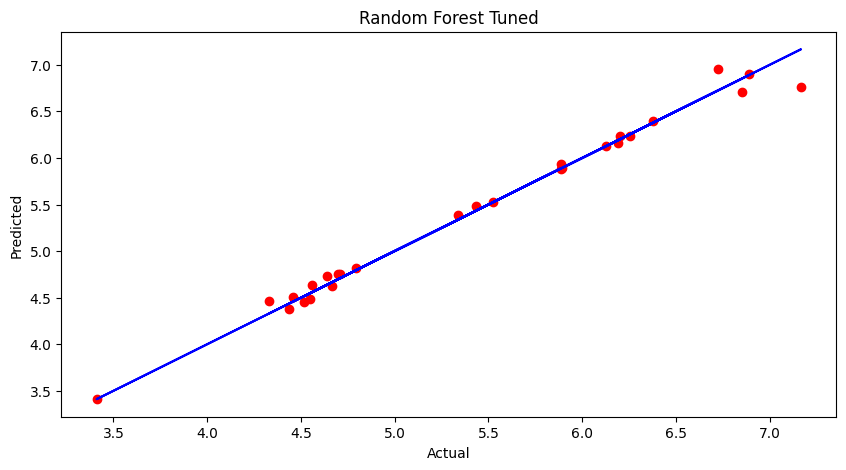

In [ ]:
# Random Forest
rf_tuned_pred = rf_tuned.predict(X_test)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, rf_tuned_pred, color='red')
plt.plot(y_test, y_test, color='blue')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest Tuned')
plt.show()

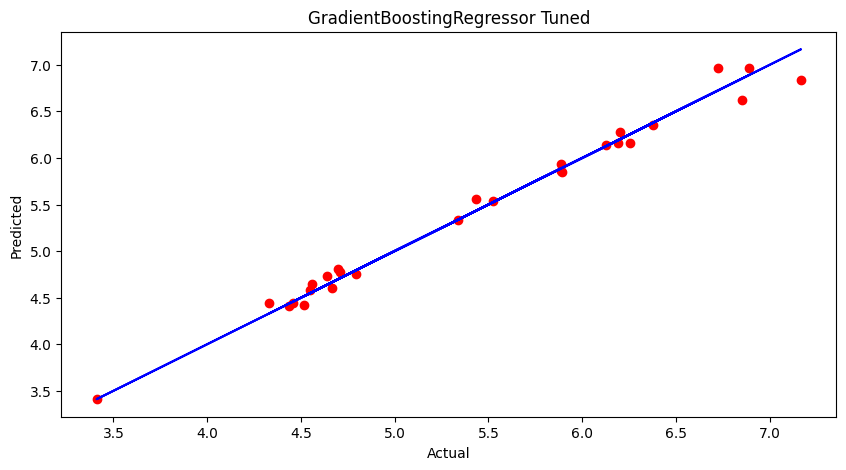

In [ ]:
# GradientBoostingRegressor
gb_tuned_pred = gb_tuned.predict(X_test)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, gb_tuned_pred, color='red')
plt.plot(y_test, y_test, color='blue')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('GradientBoostingRegressor Tuned')
plt.show()

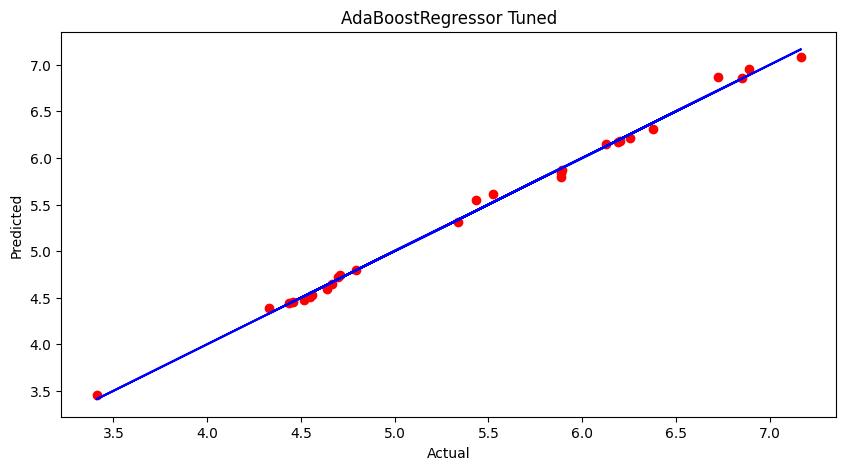

In [ ]:
# AdaBoostRegressor
ada_tuned_pred = ada_tuned.predict(X_test)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, ada_tuned_pred, color='red')
plt.plot(y_test, y_test, color='blue')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('AdaBoostRegressor Tuned')
plt.show()

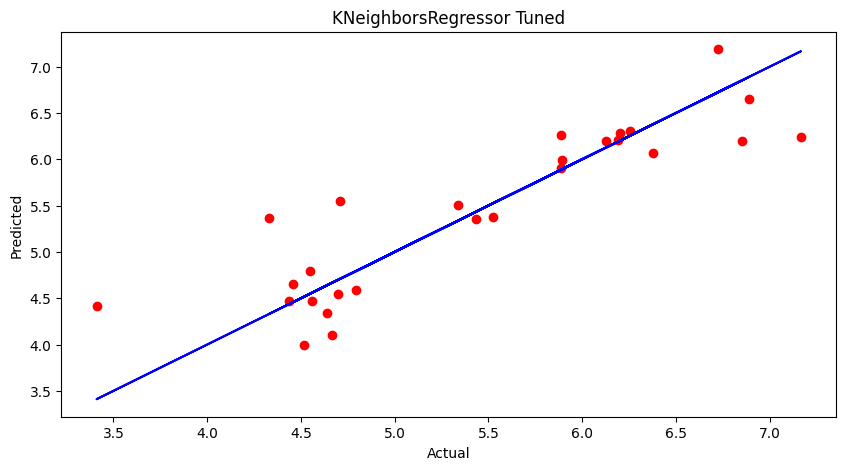

In [ ]:
# KNeighborsRegressor
knn_tuned_pred = knn_tuned.predict(X_test)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, knn_tuned_pred, color='red')
plt.plot(y_test, y_test, color='blue')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('KNeighborsRegressor Tuned')
plt.show()